# How to resume this notebook (run first)

1. Run the next code cell ("RESUME") to mount Drive and copy saved artifacts into the workspace.
2. After the RESUME cell finishes, re-run only the small setup cells you need:
   - model architecture definition cell (so `model` / `model_cpu` exist)
   - dataset creation / `test_ds` cell
3. Run the smoke-test / inference cells (there are example cells below) to verify everything works.
4. Do NOT re-run long training or full grid-search cells unless you intentionally want to retrain.

If Drive is mounted on a different path, edit `PROJECT_DIR` in the RESUME cell.

In [ ]:
# RESUME: run this cell first after opening the notebook
from pathlib import Path
import shutil, os
from google.colab import drive

# 1) Mount Drive
drive.mount('/content/drive', force_remount=True)
# 2) Set your project folder on Drive (edit if different)
PROJECT_DIR = Path("/content/drive/MyDrive/iitroorkee_flood_project")
print("Project dir:", PROJECT_DIR)
print("Drive contents:", sorted([p.name for p in PROJECT_DIR.glob("*")]))

# 3) Copy important artifacts into the local workspace (optional)
for name in ["model.onnx", "best_model.pth", "outputs_export.zip", "README.md", "best_config.json"]:
    src = PROJECT_DIR / name
    if src.exists():
        dst = Path.cwd() / src.name
        shutil.copy(src, dst)
        print("Copied", src.name, "->", dst)
    else:
        print("Not found on Drive (skipping):", src.name)

# 4) Quick ONNX smoke test if test_ds already exists in memory (safe, fast)
try:
    import numpy as np, onnxruntime as ort
    if 'test_ds' in globals():
        sess = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])
        input_name = sess.get_inputs()[0].name
        img_t, _ = test_ds[0]
        arr = img_t.cpu().numpy().astype('float32')
        if arr.ndim == 2:
            inp_np = arr[np.newaxis, np.newaxis, ...]
        elif arr.ndim == 3 and arr.shape[0] in (1,3):
            inp_np = arr[np.newaxis, ...]
        else:
            inp_np = np.ascontiguousarray(arr.astype('float32'))
        out = sess.run(None, {input_name: inp_np})[0]
        print("ONNX runtime output shape:", np.array(out).shape)
    else:
        print("test_ds not present. After running dataset setup, run numeric-compare or smoke test cells.")
except Exception as e:
    print("ONNX smoke test skipped (onnxruntime missing or error):", e)

print("Resume cell finished. Now re-run only the setup/model definition cells needed (no long training).")

The Project steps start from here!

In [7]:
# Run first. Colab usually has torch preinstalled; we install ONNX tooling and helpers.
!pip install -q onnx onnxruntime onnxscript albumentations imageio opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 19.2 MB/s eta 0:00:00


In [8]:
import os, random, math, glob
from pathlib import Path
import numpy as np
import cv2
import imageio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Settings (no edits required for the provided synthetic dataset)
ROOT = Path("/content/flood_example")    # will contain generated data & outputs
IMG_SIZE = 128
CHANNELS = 1
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [9]:
# This generates synthetic single-channel images and binary masks (simple ellipses)
def ensure_dir(p):
    os.makedirs(p, exist_ok=True)

train_n = 200
val_n = 40
test_n = 40

base = ROOT
images_dir = base / "images"
masks_dir  = base / "masks"
for split in ("train","val","test"):
    ensure_dir(images_dir / split)
    ensure_dir(masks_dir / split)

def draw_random_mask(h,w):
    mask = np.zeros((h,w), dtype=np.uint8)
    # draw 1-3 random ellipses / polygons as "water"
    n_shapes = random.randint(1,3)
    for _ in range(n_shapes):
        center = (random.randint(0,w-1), random.randint(0,h-1))
        axes = (random.randint(w//10, w//4), random.randint(h//10, h//4))
        angle = random.randint(0,360)
        cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)
    # optional blur to produce soft edges
    mask = cv2.GaussianBlur(mask, (7,7), 0)
    mask = (mask > 127).astype(np.uint8) * 255
    return mask

def synth_image_from_mask(mask):
    h,w = mask.shape
    # background with gradient + noise
    bg = np.linspace(30,200,w, dtype=np.uint8)
    bg = np.tile(bg, (h,1))
    noise = np.random.normal(0,12,(h,w)).astype(np.int16)
    img = np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    # overlay "water" as darker region (lower intensity)
    img[mask==255] = img[mask==255] // 3
    # small blur
    img = cv2.GaussianBlur(img, (3,3), 0)
    return img

def save_split(n, split_name):
    for i in range(n):
        mask = draw_random_mask(IMG_SIZE, IMG_SIZE)
        img = synth_image_from_mask(mask)
        img_path = images_dir / split_name / f"{split_name}_{i:04d}.png"
        mask_path = masks_dir / split_name / f"{split_name}_{i:04d}.png"
        cv2.imwrite(str(img_path), img)
        cv2.imwrite(str(mask_path), mask)

# generate data if not already present
if not (images_dir / "train").exists():
    print("Generating synthetic dataset (this may take ~20-60s)...")
    save_split(train_n, "train")
    save_split(val_n, "val")
    save_split(test_n, "test")
    print("Done generating synthetic dataset at", base)
else:
    print("Synthetic dataset already present at", base)

Synthetic dataset already present at /content/flood_example


In [10]:
# Generate the synthetic dataset the notebook expects
import os, random, cv2, numpy as np
from pathlib import Path
ROOT = Path("/content/flood_example")
IMG_SIZE = 128
train_n, val_n, test_n = 200, 40, 40

def ensure_dir(p): os.makedirs(p, exist_ok=True)
images_dir = ROOT / "images"; masks_dir = ROOT / "masks"
for s in ("train","val","test"):
    ensure_dir(images_dir / s); ensure_dir(masks_dir / s)

def draw_random_mask(h,w):
    mask = np.zeros((h,w), dtype=np.uint8)
    for _ in range(random.randint(1,3)):
        c = (random.randint(0,w-1), random.randint(0,h-1))
        axes = (random.randint(w//10, w//4), random.randint(h//10, h//4))
        angle = random.randint(0,360)
        cv2.ellipse(mask, c, axes, angle, 0, 360, 255, -1)
    mask = cv2.GaussianBlur(mask, (7,7), 0)
    return (mask > 127).astype(np.uint8) * 255

def synth_image_from_mask(mask):
    h,w = mask.shape
    bg = np.tile(np.linspace(30,200,w, dtype=np.uint8), (h,1))
    noise = np.random.normal(0,12,(h,w)).astype(np.int16)
    img = np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    img[mask==255] = img[mask==255] // 3
    return cv2.GaussianBlur(img, (3,3), 0)

def save_split(n, split):
    for i in range(n):
        mask = draw_random_mask(IMG_SIZE, IMG_SIZE)
        img = synth_image_from_mask(mask)
        cv2.imwrite(str(images_dir / split / f"{split}_{i:04d}.png"), img)
        cv2.imwrite(str(masks_dir  / split / f"{split}_{i:04d}.png"), mask)

# generate only if missing
if not any((images_dir/"train").glob("*.png")):
    print("Generating synthetic dataset...")
    save_split(train_n, "train")
    save_split(val_n, "val")
    save_split(test_n, "test")
    print("Done.")
else:
    print("Synthetic dataset already present.")

Generating synthetic dataset...
Done.


In [11]:
# Simple Dataset with explicit normalization (no albumentations)
import glob
from torch.utils.data import Dataset, DataLoader

MEAN = 0.5   # normalization mean used in the rest of the notebook
STD  = 0.5   # normalization std

class FloodDatasetNorm(Dataset):
    def __init__(self, images_dir, masks_dir, split="train", img_size=128, mean=MEAN, std=STD):
        self.images = sorted(glob.glob(str(images_dir / split / "*.png")))
        self.masks  = sorted(glob.glob(str(masks_dir  / split / "*.png")))
        assert len(self.images) == len(self.masks), "images/masks count mismatch"
        self.img_size = img_size
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = cv2.imread(self.images[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.masks[idx],  cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None:
            raise RuntimeError("Failed to read image/mask at idx " + str(idx))
        # resize to consistent size
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        # scale to [0,1] then normalize
        img = img.astype(np.float32) / 255.0
        img = (img - self.mean) / self.std
        mask = (mask.astype(np.float32) / 255.0)
        # convert to tensors: CxHxW and 1xHxW
        img = torch.from_numpy(img).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        mask = (mask > 0.5).float()
        return img, mask

# create datasets and dataloaders (num_workers=0 to avoid multiprocessing/pickle issues)
train_ds = FloodDatasetNorm(images_dir, masks_dir, split="train", img_size=IMG_SIZE, mean=MEAN, std=STD)
val_ds   = FloodDatasetNorm(images_dir, masks_dir, split="val",   img_size=IMG_SIZE, mean=MEAN, std=STD)
test_ds  = FloodDatasetNorm(images_dir, masks_dir, split="test",  img_size=IMG_SIZE, mean=MEAN, std=STD)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

Dataset sizes: 200 40 40


In [12]:
from pathlib import Path
ROOT = Path("/content/flood_example")
images_dir = ROOT / "images"
masks_dir  = ROOT / "masks"

print("ROOT:", ROOT)
for split in ("train","val","test"):
    imgs = sorted((images_dir / split).glob("*.png"))
    masks = sorted((masks_dir / split).glob("*.png"))
    print(f"{split}: images={len(imgs)} masks={len(masks)}")
    if len(imgs)>0:
        print(" first images:", [p.name for p in imgs[:5]])

ROOT: /content/flood_example
train: images=200 masks=200
 first images: ['train_0000.png', 'train_0001.png', 'train_0002.png', 'train_0003.png', 'train_0004.png']
val: images=40 masks=40
 first images: ['val_0000.png', 'val_0001.png', 'val_0002.png', 'val_0003.png', 'val_0004.png']
test: images=40 masks=40
 first images: ['test_0000.png', 'test_0001.png', 'test_0002.png', 'test_0003.png', 'test_0004.png']


In [13]:
# Quick check: confirm sample and batch shapes/types
img, mask = train_ds[0]
print("Sample img type/shape/dtype:", type(img), tuple(img.shape), img.dtype)
print("Sample mask type/shape/dtype:", type(mask), tuple(mask.shape), mask.dtype)
batch_imgs, batch_masks = next(iter(train_loader))
print("Batch shapes:", batch_imgs.shape, batch_masks.shape)   # expect [B,1,H,W] and [B,1,H,W]

Sample img type/shape/dtype: <class 'torch.Tensor'> (1, 128, 128) torch.float32
Sample mask type/shape/dtype: <class 'torch.Tensor'> (1, 128, 128) torch.float32
Batch shapes: torch.Size([16, 1, 128, 128]) torch.Size([16, 1, 128, 128])


Sample img type/shape/dtype: <class 'torch.Tensor'> (1, 128, 128) torch.float32
Sample mask type/shape/dtype: <class 'torch.Tensor'> (1, 128, 128) torch.float32
Batch shapes: torch.Size([16, 1, 128, 128]) torch.Size([16, 1, 128, 128])
Saved overlay to outputs/sample_overlay.png


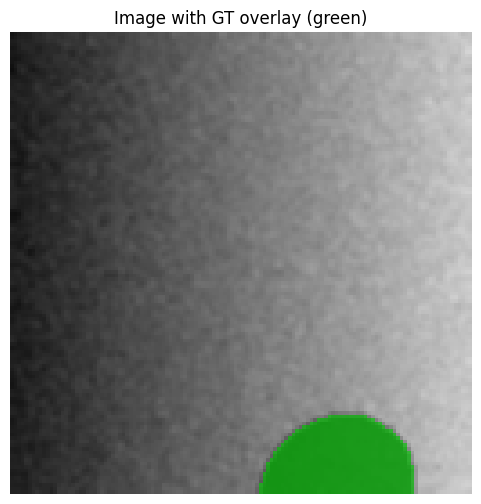

In [16]:
# Visualize one sample: undo normalization, save and display overlay
import numpy as np, cv2, matplotlib.pyplot as plt, os
os.makedirs("outputs", exist_ok=True)

# If you used different normalization, change these values here
try:
    MEAN, STD
except NameError:
    MEAN, STD = 0.5, 0.5   # fallback defaults used in the notebook

# 1) Print sample and batch shapes/types
img, mask = train_ds[0]             # img: torch.Tensor CxHxW, mask: torch.Tensor 1xHxW
print("Sample img type/shape/dtype:", type(img), tuple(img.shape), img.dtype)
print("Sample mask type/shape/dtype:", type(mask), tuple(mask.shape), mask.dtype)
batch_imgs, batch_masks = next(iter(train_loader))
print("Batch shapes:", batch_imgs.shape, batch_masks.shape)   # expect [B,1,H,W]

# 2) Undo normalization and convert to uint8 for visualization
# img is CxHxW single-channel; squeeze to HxW
img_np = img.cpu().numpy().squeeze()   # HxW, float32 normalized
img_vis = ((img_np * STD) + MEAN) * 255.0
img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)

# mask to binary HxW uint8
mask_np = (mask.cpu().numpy().squeeze() > 0.5).astype(np.uint8) * 255

# 3) Create colored overlay: GT in green
canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
overlay = canvas.copy()
overlay[mask_np == 255] = (0,255,0)   # green for ground-truth
alpha = 0.5
cv2.addWeighted(overlay, alpha, canvas, 1 - alpha, 0, canvas)

# 4) Save overlay PNG
out_path = "outputs/sample_overlay.png"
cv2.imwrite(out_path, canvas)
print("Saved overlay to", out_path)

# 5) Display inline (convert BGR->RGB for matplotlib)
plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Image with GT overlay (green)")
plt.show()

In [17]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self,x): return self.net(x)

class UNetMini(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, features=[32,64,128]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()
        prev = in_ch
        for f in features:
            self.downs.append(DoubleConv(prev, f))
            self.pools.append(nn.MaxPool2d(2))
            prev = f
        self.bottleneck = DoubleConv(prev, prev*2)
        self.ups = nn.ModuleList()
        features_rev = list(reversed(features))
        prev = prev*2
        for f in features_rev:
            self.ups.append(nn.ConvTranspose2d(prev, f, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(prev, f))
            prev = f
        self.final = nn.Conv2d(prev, out_ch, kernel_size=1)

    def forward(self,x):
        skips=[]
        for i,d in enumerate(self.downs):
            x = d(x)
            skips.append(x)
            x = self.pools[i](x)
        x = self.bottleneck(x)
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips.pop()
            if x.shape[2:] != skip.shape[2:]:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = self.ups[i+1](x)
        x = self.final(x)
        return x

model = UNetMini(in_ch=CHANNELS, out_ch=1).to(DEVICE)
print(model)

UNetMini(
  (downs): ModuleList(
    (0): DoubleConv(
      (net): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (2): DoubleConv(
      (net): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
  )
  (pools): ModuleList(
    (0-2): 3 x MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  

In [18]:
# quick training to produce a usable model (keeps runtime short)
epochs = 6
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

def iou_numpy(pred, target, eps=1e-7):
    pred = (pred > 0.5).astype(np.uint8)
    target = (target > 0.5).astype(np.uint8)
    inter = (pred & target).sum()
    union = (pred | target).sum()
    return inter / (union + eps)

for ep in range(epochs):
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        preds = model(imgs)
        loss = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    running_loss /= len(train_loader.dataset)
    # validation quick
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item() * imgs.size(0)
    val_loss /= len(val_loader.dataset)
    print(f"Epoch {ep+1}/{epochs} train_loss={running_loss:.4f} val_loss={val_loss:.4f}")
print("Training finished.")

Epoch 1/6 train_loss=0.6062 val_loss=0.5046
Epoch 2/6 train_loss=0.4147 val_loss=0.3280
Epoch 3/6 train_loss=0.2950 val_loss=0.2899
Epoch 4/6 train_loss=0.3525 val_loss=0.2826
Epoch 5/6 train_loss=0.2645 val_loss=0.2737
Epoch 6/6 train_loss=0.2286 val_loss=0.2315
Training finished.


In [19]:
os.makedirs("outputs", exist_ok=True)
model.eval()
ious=[]
saved=0
max_save = 12

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        preds = model(imgs)
        probs = torch.sigmoid(preds)
        preds_bin = (probs > 0.5).float()
        for i in range(imgs.size(0)):
            img = imgs[i].cpu().numpy().squeeze()   # CxHxW -> HxW
            # undo normalization (MEAN/STD)
            img_vis = ((img * STD) + MEAN) * 255.0
            img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)
            mask_np = (masks[i].cpu().numpy().squeeze() > 0.5).astype(np.uint8)
            pred_np = preds_bin[i].cpu().numpy().squeeze().astype(np.uint8)
            # compute iou
            iou = iou_numpy(pred_np, mask_np)
            ious.append(iou)
            if saved < max_save:
                # create overlay: GT green, pred red
                canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
                overlay = canvas.copy()
                overlay[mask_np==1] = (0,255,0)
                overlay[pred_np==1] = (0,0,255)
                cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0, canvas)
                cv2.imwrite(f"outputs/test_overlay_{saved:02d}.png", canvas)
                saved += 1

if len(ious)>0:
    print("Test IoU mean/median/min/max:", np.mean(ious), np.median(ious), np.min(ious), np.max(ious))
else:
    print("No test IoU calculated.")
# produce a GIF of overlays
pngs = sorted(glob.glob("outputs/test_overlay_*.png"))
if pngs:
    frames = [imageio.imread(p) for p in pngs]
    imageio.mimsave("outputs/demo.gif", frames, fps=1)
    print("Saved outputs/demo.gif and overlay PNGs in outputs/")

Test IoU mean/median/min/max: 0.4728867843278676 0.5544882227979459 0.0 0.8384932920103977


/tmp/ipykernel_1917/1592942024.py:40: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames = [imageio.imread(p) for p in pngs]


Saved outputs/demo.gif and overlay PNGs in outputs/


In [21]:
# Pre-check: ensure model, dataset, IMG_SIZE and CHANNELS are present and show a sample
import torch, numpy as np
from pathlib import Path

print("model in globals():", 'model' in globals())
if 'model' in globals():
    try:
        p = next(model.parameters())
        print("model param device/type:", p.device, type(model))
    except Exception as e:
        print("model exists but next(param) failed:", e)

print("IMG_SIZE:", globals().get('IMG_SIZE'))
print("CHANNELS:", globals().get('CHANNELS'))
print("test_ds exists:", 'test_ds' in globals())

# show a sample shape from test_ds
if 'test_ds' in globals():
    try:
        img, mask = test_ds[0]
        print("sample shapes:", getattr(img, 'shape', None), getattr(mask, 'shape', None))
    except Exception as e:
        print("Could not read sample from test_ds:", e)
else:
    print("test_ds not found - run dataset cell first")

model in globals(): True
model param device/type: cuda:0 <class '__main__.UNetMini'>
IMG_SIZE: 128
CHANNELS: 1
test_ds exists: True
sample shapes: torch.Size([1, 128, 128]) torch.Size([1, 128, 128])


**ONNX Deployment and Validation (Optional):**

The following cells contain optional ONNX export and validation procedures for deployment compatibility. The primary project evaluation was performed using the PyTorch model. These cells are retained to document the potential deployment workflow but were not required for the primary segmentation results.

In [ ]:
# Export trained model to ONNX (safe). Run only after model is defined/trained.
import os, torch
from pathlib import Path

# Ensure CHANNELS and IMG_SIZE exist; fall back to sensible defaults if not
if 'CHANNELS' not in globals():
    CHANNELS = 1
    print("CHANNELS not found, defaulting to 1")
if 'IMG_SIZE' not in globals():
    IMG_SIZE = 128
    print("IMG_SIZE not found, defaulting to 128")

# Install onnxscript if needed for some torch versions
try:
    import onnxscript  # noqa: F401
except Exception:
    print("Installing onnxscript...")
    !pip install -q onnxscript
    import onnxscript  # noqa: F401

import onnx
onnx_path = Path("model.onnx")

# Move model to CPU and set eval
model_cpu = model.to("cpu").eval()

# Dummy input matching your channels and size
dummy = torch.randn(1, CHANNELS, IMG_SIZE, IMG_SIZE, dtype=torch.float32)

# Quick forward to ensure model runs on CPU
with torch.no_grad():
    example_out = model_cpu(dummy)
if isinstance(example_out, torch.Tensor):
    print("Example output shape (torch):", tuple(example_out.shape))
else:
    print("Example forward produced non-tensor output; inspect model.")

# Export to ONNX
try:
    torch.onnx.export(
        model_cpu,
        dummy,
        str(onnx_path),
        opset_version=11,
        input_names=["input"],
        output_names=["output"],
        dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
        do_constant_folding=True
    )
    print("Saved ONNX to", onnx_path)
except Exception as e:
    print("Export error:", type(e).__name__, e)
    raise

In [ ]:
# Validate ONNX and compare ONNX Runtime output vs. PyTorch on one real sample
import onnx, onnxruntime as ort, numpy as np, torch

# 1) Load & check ONNX model file
onnx_path = "model.onnx"
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print("ONNX model loaded and validated:", onnx_path)

# 2) Create an onnxruntime session (CPU)
sess = ort.InferenceSession(onnx_path)
input_meta = sess.get_inputs()[0]
output_meta = sess.get_outputs()
input_name = input_meta.name
print("ONNX input name/shape:", input_name, input_meta.shape)
print("ONNX outputs:", [o.name + str(tuple(o.shape)) for o in output_meta])

# 3) Prepare one real sample from test_ds as numpy 1xCxHxW float32
if 'test_ds' not in globals():
    raise RuntimeError("test_ds not found - run dataset creation cell first")
img_tensor, gt_mask = test_ds[0]   # expected: torch.Tensor CxHxW
if isinstance(img_tensor, torch.Tensor):
    sample_np = img_tensor.unsqueeze(0).cpu().numpy().astype(np.float32)  # 1xCxHxW
else:
    sample_np = np.expand_dims(np.asarray(img_tensor), 0).astype(np.float32)
print("Sample_np shape/dtype:", sample_np.shape, sample_np.dtype)

# 4) Run ONNX Runtime inference
try:
    out_onnx = sess.run(None, {input_name: sample_np})[0]
    print("ONNX output shape:", out_onnx.shape, "min/max/mean:", float(out_onnx.min()), float(out_onnx.max()), float(out_onnx.mean()))
except Exception as e:
    print("ONNX runtime inference failed:", type(e).__name__, e)
    print("Available ONNX inputs:", [(i.name, i.shape) for i in sess.get_inputs()])
    print("Available ONNX outputs:", [(o.name, o.shape) for o in sess.get_outputs()])
    raise

# 5) Run same sample through PyTorch CPU model and compare
model_cpu = model_cpu.eval()  # created during export cell
with torch.no_grad():
    t = torch.from_numpy(sample_np).float()
    out_torch = model_cpu(t).cpu().numpy()

diff = out_torch - out_onnx
abs_diff = np.abs(diff)
print("PyTorch out shape:", out_torch.shape)
print("abs_diff max:", float(abs_diff.max()), "mean:", float(abs_diff.mean()), "L2:", float(np.linalg.norm(diff.ravel())))
scale = max(1.0, float(np.abs(out_torch).max()))
print("relative max diff:", float(abs_diff.max() / scale))

In [ ]:
# Pack outputs and download ONNX (use only if you want to download from Colab)
from google.colab import files
import shutil
if Path("model.onnx").exists():
    files.download("model.onnx")
else:
    print("model.onnx not found")

if Path("outputs").exists():
    shutil.make_archive("outputs_zip", "zip", "outputs")
    files.download("outputs_zip.zip")
else:
    print("outputs/ directory not found (no overlays saved?)")

In [22]:
# Create GT+prediction overlays for the first N test samples
import numpy as np, cv2, os, torch
os.makedirs("outputs/pred_overlays", exist_ok=True)

# Ensure mean/std are available (change if you used different values)
try:
    MEAN, STD
except NameError:
    MEAN, STD = 0.5, 0.5

# Ensure we have a CPU copy of the model
if 'model_cpu' not in globals():
    model_cpu = model.to("cpu").eval()
else:
    model_cpu = model_cpu.eval()

N = 12   # number of overlays to produce
count = 0
with torch.no_grad():
    for i in range(len(test_ds)):
        img_t, mask_t = test_ds[i]  # img_t: CxHxW
        sample_np = img_t.unsqueeze(0).cpu().numpy().astype(np.float32)
        # Inference using the CPU model
        t = torch.from_numpy(sample_np).float()
        out = model_cpu(t).cpu().numpy()[0,0]   # HxW logits
        prob = 1.0 / (1.0 + np.exp(-out))       # sigmoid
        pred = (prob > 0.5).astype(np.uint8) * 255
        # undo normalization for display
        img_vis = ((img_t.cpu().numpy().squeeze() * STD) + MEAN) * 255.0
        img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)
        mask_np = (mask_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8) * 255
        # canvas and colored overlay: GT green, pred red
        canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
        overlay = canvas.copy()
        overlay[mask_np == 255] = (0,255,0)      # green GT
        overlay[pred == 255] = (0,0,255)         # red pred
        cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0, canvas)
        out_path = f"outputs/pred_overlays/pred_overlay_{i:03d}.png"
        cv2.imwrite(out_path, canvas)
        count += 1
        if count >= N:
            break

print(f"Saved {count} overlays to outputs/pred_overlays/")

Saved 12 overlays to outputs/pred_overlays/


In [ ]:
# Download model.onnx and a zip of outputs/
from pathlib import Path
from google.colab import files
import shutil

if Path("model.onnx").exists():
    print("Downloading model.onnx...")
    files.download("model.onnx")
else:
    print("model.onnx not found")

if Path("outputs").exists():
    shutil.make_archive("outputs_zip", "zip", "outputs")
    print("Downloading outputs_zip.zip...")
    files.download("outputs_zip.zip")
else:
    print("outputs/ directory not found")

In [ ]:
# Check that model.onnx and outputs exist, list some files and display a sample overlay
from pathlib import Path
from IPython.display import Image, display

print("model.onnx exists:", Path("model.onnx").exists())
print("outputs/ exists:", Path("outputs").exists())

# list a few overlay files if present
ov_dir = Path("outputs/pred_overlays")
if ov_dir.exists():
    files = sorted(ov_dir.glob("pred_overlay_*.png"))
    print("Found", len(files), "pred overlays. Example files:", [p.name for p in files[:6]])
    if files:
        display(Image(str(files[0])))
else:
    print("No outputs/pred_overlays found. Check outputs/ directory.")

In [ ]:
# Copy model.onnx and outputs_zip.zip to Google Drive so you can download them
from pathlib import Path
from google.colab import drive
import shutil

drive.mount('/content/drive')   # follow the link and grant permission if prompted

dst = Path("/content/drive/MyDrive/flood_example_export")
dst.mkdir(parents=True, exist_ok=True)

# copy model.onnx if present
if Path("model.onnx").exists():
    shutil.copy("model.onnx", dst / "model.onnx")
    print("Copied model.onnx ->", str(dst / "model.onnx"))
else:
    print("model.onnx not found in notebook root")

# zip and copy outputs folder if present
if Path("outputs").exists():
    shutil.make_archive("outputs_zip", "zip", "outputs")
    shutil.copy("outputs_zip.zip", dst / "outputs_zip.zip")
    print("Copied outputs_zip.zip ->", str(dst / "outputs_zip.zip"))
else:
    print("outputs/ directory not found - nothing to zip")

print("Now open your Google Drive at: My Drive/flood_example_export and download the files from there.")

In [27]:
from pathlib import Path
for p in sorted(Path("outputs").rglob("*")):
    if p.is_file():
        print(p, p.stat().st_size)

outputs/demo.gif 193450
outputs/pred_overlays/pred_overlay_000.png 23352
outputs/pred_overlays/pred_overlay_001.png 23186
outputs/pred_overlays/pred_overlay_002.png 23306
outputs/pred_overlays/pred_overlay_003.png 22573
outputs/pred_overlays/pred_overlay_004.png 23002
outputs/pred_overlays/pred_overlay_005.png 23229
outputs/pred_overlays/pred_overlay_006.png 23491
outputs/pred_overlays/pred_overlay_007.png 23457
outputs/pred_overlays/pred_overlay_008.png 23826
outputs/pred_overlays/pred_overlay_009.png 23206
outputs/pred_overlays/pred_overlay_010.png 23247
outputs/pred_overlays/pred_overlay_011.png 23541
outputs/sample_overlay.png 23108
outputs/test_overlay_00.png 23352
outputs/test_overlay_01.png 23186
outputs/test_overlay_02.png 23306
outputs/test_overlay_03.png 22573
outputs/test_overlay_04.png 23002
outputs/test_overlay_05.png 23229
outputs/test_overlay_06.png 23491
outputs/test_overlay_07.png 23457
outputs/test_overlay_08.png 23826
outputs/test_overlay_09.png 23206
outputs/test_ov

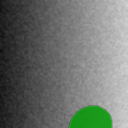

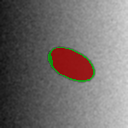

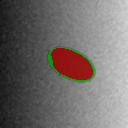

In [28]:
from IPython.display import Image, display
display(Image("outputs/sample_overlay.png"))
display(Image("outputs/pred_overlays/pred_overlay_000.png"))
display(Image("outputs/demo.gif"))

Sample 0 IoU = 0.8218 (intersection=950, union=1156)


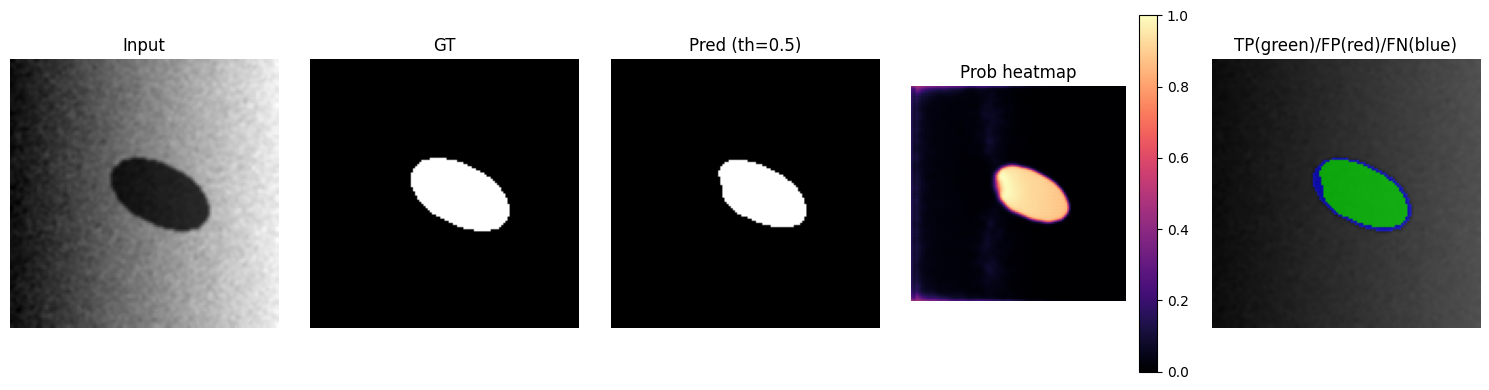

In [29]:
# Inspect one sample in detail: print IoU and show GT/pred/prob/overlay
import numpy as np, cv2, torch
from IPython.display import display, Image
import matplotlib.pyplot as plt

# choose index (0..len(test_ds)-1)
i = 0

# get sample
img_t, gt_t = test_ds[i]           # CxHxW tensors
img_np = img_t.cpu().numpy().squeeze()   # HxW normalized
gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)

# run model (CPU)
model_cpu = model_cpu.eval() if 'model_cpu' in globals() else model.to("cpu").eval()
with torch.no_grad():
    inp = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()  # 1x1xHxW
    out = model_cpu(inp).cpu().numpy()[0,0]    # HxW logits
prob = 1.0/(1.0+np.exp(-out))
pred = (prob > 0.5).astype(np.uint8)

# IoU
intersection = np.logical_and(pred, gt).sum()
union = np.logical_or(pred, gt).sum()
iou = intersection / union if union>0 else float('nan')
print(f"Sample {i} IoU = {iou:.4f} (intersection={intersection}, union={union})")

# Visualizations
# undo normalization for display (adjust MEAN/STD if different)
try:
    MEAN, STD
except NameError:
    MEAN, STD = 0.5, 0.5
img_vis = ((img_np * STD) + MEAN) * 255.0
img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)

# colored TP/FP/FN overlay: TP green, FP red, FN blue
h,w = gt.shape
canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
overlay = np.zeros_like(canvas)
tp = (pred==1) & (gt==1)
fp = (pred==1) & (gt==0)
fn = (pred==0) & (gt==1)
overlay[tp] = (0,255,0)   # green
overlay[fp] = (0,0,255)   # red
overlay[fn] = (255,0,0)   # blue
blend = cv2.addWeighted(overlay, 0.6, canvas, 0.4, 0)

# plot grid
fig, axes = plt.subplots(1,5, figsize=(15,4))
axes[0].imshow(img_vis, cmap='gray'); axes[0].set_title("Input")
axes[1].imshow(gt, cmap='gray'); axes[1].set_title("GT")
axes[2].imshow(pred, cmap='gray'); axes[2].set_title("Pred (th=0.5)")
axes[3].imshow(prob, cmap='magma'); axes[3].set_title("Prob heatmap"); plt.colorbar(plt.cm.ScalarMappable(cmap='magma'), ax=axes[3])
axes[4].imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB)); axes[4].set_title("TP(green)/FP(red)/FN(blue)")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [30]:
# Helpers - combined loss (BCE + Dice), postprocessing, TTA, device
import torch, numpy as np, cv2, os
from pathlib import Path

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE =", DEVICE)

# 1) Dice loss on logits + combined loss (BCE + Dice)
import torch.nn.functional as F
bce_loss_fn = torch.nn.BCEWithLogitsLoss()

def dice_loss_logits(pred_logits, target, eps=1e-6):
    # pred_logits: [B,1,H,W], target: [B,1,H,W] (0/1)
    pred = torch.sigmoid(pred_logits)
    num = 2.0 * (pred * target).sum(dim=(2,3))
    den = pred.sum(dim=(2,3)) + target.sum(dim=(2,3)) + eps
    loss = 1.0 - (num / den)
    return loss.mean()

def combined_loss(pred_logits, target, alpha=0.5):
    # alpha weights BCE (alpha) vs Dice (1-alpha)
    b = bce_loss_fn(pred_logits, target)
    d = dice_loss_logits(pred_logits, target)
    return alpha * b + (1.0 - alpha) * d

# 2) Postprocessing: remove small connected components
def postprocess_mask(binary_mask, min_area=100):
    """
    binary_mask: HxW (0/255 or 0/1). returns HxW uint8 0/255
    """
    mask = (binary_mask > 0).astype(np.uint8) * 255
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for lab in range(1, num_labels):
        area = int(stats[lab, cv2.CC_STAT_AREA])
        if area >= min_area:
            out[labels == lab] = 255
    return out

# 3) Simple TTA (identity, hflip, vflip)
def tta_predict_numpy(model, img_tensor):  # img_tensor: torch tensor 1xCxHxW on device
    model = model.eval()
    with torch.no_grad():
        preds = []
        x = img_tensor
        preds.append(torch.sigmoid(model(x)).cpu().numpy())
        # hflip
        xh = torch.flip(x, dims=[-1])
        p = torch.sigmoid(model(xh)).cpu().numpy()
        preds.append(np.flip(p, axis=-1))
        # vflip
        xv = torch.flip(x, dims=[-2])
        p = torch.sigmoid(model(xv)).cpu().numpy()
        preds.append(np.flip(p, axis=-2))
    return np.mean(preds, axis=0)  # 1x1xHxW

# 4) Ensure MEAN/STD exist for visualization undo
try:
    MEAN, STD
except NameError:
    MEAN, STD = 0.5, 0.5
    print("MEAN/STD not found; defaulting to", MEAN, STD)

# 5) Create outputs dir
os.makedirs("outputs/pred_overlays", exist_ok=True)

DEVICE = cuda


In [ ]:
# Quick pre-check before training
print("model in globals():", 'model' in globals())
print("train_loader in globals():", 'train_loader' in globals())
print("val_loader in globals():", 'val_loader' in globals())
print("test_ds in globals():", 'test_ds' in globals())
print("DEVICE:", globals().get('DEVICE'))

# show one sample shapes if available
if 'train_loader' in globals():
    try:
        b = next(iter(train_loader))
        print("train batch shapes/types:", type(b), [x.shape for x in b])
    except Exception as e:
        print("Could not iterate train_loader:", e)
if 'val_loader' in globals():
    try:
        b = next(iter(val_loader))
        print("val batch shapes/types:", [x.shape for x in b])
    except Exception as e:
        print("Could not iterate val_loader:", e)

In [ ]:
# Train using combined loss (handles ReduceLROnPlateau verbose mismatch)
import time, numpy as np, torch
from pathlib import Path
from tqdm.auto import tqdm

# Sanity checks
if 'model' not in globals():
    raise RuntimeError("model is not defined. Run the model definition cell first.")
if 'train_loader' not in globals() or 'val_loader' not in globals():
    raise RuntimeError("train_loader or val_loader not found. Run dataset/DataLoader cells first.")
if 'combined_loss' not in globals():
    raise RuntimeError("combined_loss not found. Run Cell 1 (helpers) first.")

# Device & move model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", DEVICE)
model = model.to(DEVICE)

# Hyperparameters
EPOCHS = 6   # set to 1 for a quick smoke test
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Create scheduler, but be compatible with older torch versions that don't accept verbose
try:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)
except TypeError:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Helper: evaluate mean IoU on a loader
def evaluate_mean_iou(dataloader, model, device=DEVICE):
    model.eval()
    ious = []
    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)
            out = model(imgs)  # logits
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            inter = (preds * masks).sum(dim=(1,2,3))
            union = ((preds + masks) > 0).sum(dim=(1,2,3))
            iou = torch.where(union>0, inter.float()/union.float(), torch.ones_like(inter).float())
            ious.extend(iou.cpu().numpy().tolist())
    return float(np.mean(ious)) if ious else float('nan')

# Training loop
best_val = -1.0
best_path = Path("best_model.pth")

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    it = 0
    t0 = time.time()
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)  # logits
        loss = combined_loss(out, masks, alpha=0.5)
        loss.backward()
        optimizer.step()
        running_loss += float(loss.item())
        it += 1
    train_loss = running_loss / max(1, it)
    val_iou = evaluate_mean_iou(val_loader, model, device=DEVICE)
    print(f"Epoch {epoch} train_loss={train_loss:.4f} val_iou={val_iou:.4f} time={(time.time()-t0):.1f}s")
    # scheduler.step expects a metric; use 1 - val_iou so LR reduces when val_iou plateaus
    scheduler.step(1.0 - val_iou)
    if val_iou > best_val:
        best_val = val_iou
        torch.save(model.state_dict(), str(best_path))
        print("Saved new best model:", best_path)

print("Training finished. Best val IoU:", best_val)

# Load best model to CPU for inference
model.load_state_dict(torch.load(str(best_path), map_location="cpu"))
model_cpu = model.to("cpu").eval()

In [ ]:
from pathlib import Path
print("best_model.pth exists:", Path("best_model.pth").exists())
# show last 10 lines of notebook output if available (simple check)
!tail -n 30 /content/drive/MyDrive/colab-notes || true

In [ ]:
def evaluate_thresholds(probs, gts, threshs=np.linspace(0.1,0.9,33)):
    # probs: float array (N,1,H,W), gts: array (N,1,H,W) with 0/1 (maybe float)
    # convert ground-truth to boolean once
    gts_bool = (gts > 0.5)
    best_t, best_iou = None, -1.0
    for t in threshs:
        preds = (probs > t)          # boolean
        inter = np.logical_and(preds, gts_bool).sum(axis=(1,2,3))
        union = np.logical_or(preds, gts_bool).sum(axis=(1,2,3))
        ious = np.where(union>0, inter/union, 1.0)
        mean_iou = ious.mean()
        if mean_iou > best_iou:
            best_iou = mean_iou
            best_t = t
    return best_t, best_iou

In [ ]:
# Run this cell to compute / confirm val probs and run threshold search, then print the result
import numpy as np, torch
from pathlib import Path

# If probs_val/gts_val not present, compute them (uses val_loader & model_cpu)
if 'probs_val' not in globals() or 'gts_val' not in globals():
    print("probs_val/gts_val not found — computing from val_loader now (may take a moment)...")
    if 'val_loader' not in globals():
        raise RuntimeError("val_loader not found. Run dataset/DataLoader cells first.")
    if 'model_cpu' not in globals():
        # try to load best_model.pth
        if Path("best_model.pth").exists():
            model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))
            model_cpu = model.to("cpu").eval()
            print("Loaded best_model.pth into model_cpu")
        else:
            raise RuntimeError("model_cpu and best_model.pth not found. Run training cell first.")
    # compute probs & gts
    probs_list, gts_list = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            out = model_cpu(imgs)          # logits
            p = torch.sigmoid(out).cpu().numpy()
            probs_list.append(p)
            gts_list.append(masks.cpu().numpy())
    probs_val = np.concatenate(probs_list, axis=0)
    gts_val = np.concatenate(gts_list, axis=0)
    print("Computed probs_val/gts_val")

# Print shapes/dtypes for sanity
print("probs_val shape/dtype:", probs_val.shape, probs_val.dtype)
print("gts_val shape/dtype:", gts_val.shape, gts_val.dtype)

# Ensure evaluate_thresholds is defined
if 'evaluate_thresholds' not in globals():
    raise RuntimeError("evaluate_thresholds not defined. Re-run the function definition cell (Cell A).")

# Run the threshold search and print result
best_t, best_val_iou = evaluate_thresholds(probs_val, gts_val)
print("Best threshold on val:", best_t)
print("Val IoU at best threshold:", best_val_iou)

In [ ]:
# Run test inference using best threshold and save overlays/GIF
import numpy as np, cv2, imageio, os, torch

# Settings (modify if you want)
THRESH = float(best_t)
MIN_AREA = 50      # small connected components below this are removed
USE_TTA = True     # set to False to be faster

os.makedirs("outputs/test_overlay_pp", exist_ok=True)
frames = []
ious = []
model_cpu = model_cpu.eval()

# tta_predict_numpy and postprocess_mask should be defined (Cell 1). If not, paste their definitions again.
try:
    tta_predict_numpy
    postprocess_mask
except NameError:
    raise RuntimeError("Helpers not found. Run Cell 1 (helpers) first to define tta_predict_numpy and postprocess_mask.")

for i in range(len(test_ds)):
    img_t, gt_t = test_ds[i]   # CxHxW
    img_np = img_t.cpu().numpy().squeeze()
    gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)

    inp = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()  # 1x1xHxW
    if USE_TTA:
        prob = tta_predict_numpy(model_cpu, inp)[0,0]
    else:
        with torch.no_grad():
            out = model_cpu(inp).cpu().numpy()[0,0]
            prob = 1.0/(1.0 + np.exp(-out))

    pred = (prob > THRESH).astype(np.uint8) * 255
    pred_pp = postprocess_mask(pred, min_area=MIN_AREA)
    pred_bin = (pred_pp > 0).astype(np.uint8)

    inter = int(np.logical_and(pred_bin, gt).sum())
    union = int(np.logical_or(pred_bin, gt).sum())
    iou = inter/union if union>0 else 1.0
    ious.append(iou)

    # visualization (GT green, pred red)
    try:
        MEAN, STD
    except NameError:
        MEAN, STD = 0.5, 0.5
    img_vis = ((img_np * STD) + MEAN) * 255.0
    img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)
    canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
    overlay = canvas.copy()
    overlay[gt == 1] = (0,255,0)
    overlay[pred_bin == 1] = (0,0,255)
    cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0, canvas)
    out_path = f"outputs/test_overlay_pp/test_overlay_pp_{i:03d}.png"
    cv2.imwrite(out_path, canvas)
    frames.append(imageio.imread(out_path))

print("Saved overlays:", len(frames))
print("Test IoU mean/median/min/max:", np.mean(ious), np.median(ious), np.min(ious), np.max(ious))
if frames:
    imageio.mimsave("outputs/demo_pp.gif", frames, fps=1)
    print("Saved outputs/demo_pp.gif")

In [ ]:
# Preview demo_pp.gif and some saved overlays inline
from pathlib import Path
from IPython.display import Image, display

print("demo gif exists:", Path("outputs/demo_pp.gif").exists())
print("example overlay exists:", Path("outputs/test_overlay_pp/test_overlay_pp_000.png").exists())

if Path("outputs/demo_pp.gif").exists():
    display(Image("outputs/demo_pp.gif"))

# show first 6 overlays
for p in sorted(Path("outputs/test_overlay_pp").glob("test_overlay_pp_*.png"))[:6]:
    print(p.name)
    display(Image(str(p)))

In [ ]:
# Recompute per-image IoU, list the worst N, and display them
import numpy as np, torch, cv2
from IPython.display import display, Image
from pathlib import Path

# settings — change N to show more
N = 6
THRESH = float(best_t)   # uses best_t from threshold search
MIN_AREA = 50
USE_TTA = True           # match what you used in Cell B

# helper functions (redefine if not in namespace)
def postprocess_mask(binary_mask, min_area=100):
    import cv2, numpy as np
    mask = (binary_mask > 0).astype(np.uint8) * 255
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for lab in range(1, num_labels):
        area = int(stats[lab, cv2.CC_STAT_AREA])
        if area >= min_area:
            out[labels == lab] = 255
    return out

def tta_predict_numpy(model, img_tensor):
    model = model.eval()
    with torch.no_grad():
        preds = []
        x = img_tensor
        preds.append(torch.sigmoid(model(x)).cpu().numpy())
        xh = torch.flip(x, dims=[-1])
        preds.append(np.flip(torch.sigmoid(model(xh)).cpu().numpy(), axis=-1))
        xv = torch.flip(x, dims=[-2])
        preds.append(np.flip(torch.sigmoid(model(xv)).cpu().numpy(), axis=-2))
    return np.mean(preds, axis=0)

# compute IoUs
ious = []
paths = []
model_cpu = model_cpu.eval()
for i in range(len(test_ds)):
    img_t, gt_t = test_ds[i]
    img_np = img_t.cpu().numpy().squeeze()
    gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)

    inp = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    if USE_TTA:
        prob = tta_predict_numpy(model_cpu, inp)[0,0]
    else:
        with torch.no_grad():
            out = model_cpu(inp).cpu().numpy()[0,0]
            prob = 1.0/(1.0 + np.exp(-out))

    pred = (prob > THRESH).astype(np.uint8) * 255
    pred_pp = postprocess_mask(pred, min_area=MIN_AREA)
    pred_bin = (pred_pp > 0).astype(np.uint8)

    inter = int(np.logical_and(pred_bin, gt).sum())
    union = int(np.logical_or(pred_bin, gt).sum())
    iou = inter/union if union>0 else 1.0
    ious.append(iou)
    paths.append((i, iou))

# show worst N
paths_sorted = sorted(paths, key=lambda x: x[1])[:N]
print("Worst", N, "cases (index, IoU):", paths_sorted)
for idx, iou in paths_sorted:
    out_p = f"outputs/test_overlay_pp/test_overlay_pp_{idx:03d}.png"
    print(f"Index {idx} IoU={iou:.4f}  overlay:", out_p)
    display(Image(out_p))

In [ ]:
# Cleaned: Try morphological post-processing, recompute IoUs and show worst cases
import numpy as np, torch, cv2
from IPython.display import display, Image
from pathlib import Path
import statistics

# Settings to try (tweak these)
THRESH = float(best_t)        # best_t from threshold search
MIN_AREA = 200                # increase to remove small FP islands
USE_TTA = True                # match what you used earlier
MORPH_KERNEL = 3              # closing kernel (odd int)
N_WORST = 6                   # how many worst cases to show

# helpers (use existing or redefine)
def tta_predict_numpy(model, img_tensor):
    model = model.eval()
    with torch.no_grad():
        preds = []
        x = img_tensor
        preds.append(torch.sigmoid(model(x)).cpu().numpy())
        preds.append(np.flip(torch.sigmoid(model(torch.flip(x, dims=[-1]))).cpu().numpy(), axis=-1))
        preds.append(np.flip(torch.sigmoid(model(torch.flip(x, dims=[-2]))).cpu().numpy(), axis=-2))
    return np.mean(preds, axis=0)

def postproc_morph(pred_mask, min_area=100, kernel_size=3):
    # pred_mask: HxW uint8 (0 or 255)
    mask = (pred_mask > 0).astype(np.uint8) * 255
    # morphological closing to fill small holes
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
    # fill small holes by floodfill on inverted image
    inv = 255 - closed
    h, w = inv.shape
    mask_ff = inv.copy()
    mask_temp = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(mask_ff, mask_temp, (0,0), 255)
    holes = 255 - mask_ff
    filled = cv2.bitwise_or(closed, holes)
    # remove small components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(filled, connectivity=8)
    out = np.zeros_like(filled)
    for lab in range(1, num_labels):
        area = int(stats[lab, cv2.CC_STAT_AREA])
        if area >= min_area:
            out[labels == lab] = 255
    return out

# run inference, postprocess, compute IoUs
model = model_cpu.eval()
ious = []
indices = []
out_paths = []
for i in range(len(test_ds)):
    img_t, gt_t = test_ds[i]
    img_np = img_t.cpu().numpy().squeeze()
    gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)

    inp = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    if USE_TTA:
        prob = tta_predict_numpy(model, inp)[0,0]
    else:
        with torch.no_grad():
            out = model(inp).cpu().numpy()[0,0]
            prob = 1.0/(1.0 + np.exp(-out))

    pred = (prob > THRESH).astype(np.uint8) * 255
    pred_pp = postproc_morph(pred, min_area=MIN_AREA, kernel_size=MORPH_KERNEL)
    pred_bin = (pred_pp > 0).astype(np.uint8)

    inter = int(np.logical_and(pred_bin, gt).sum())
    union = int(np.logical_or(pred_bin, gt).sum())
    iou = inter/union if union>0 else 1.0
    ious.append(iou)
    indices.append(i)

    # save overlay for display
    try:
        MEAN, STD
    except NameError:
        MEAN, STD = 0.5, 0.5
    img_vis = ((img_np * STD) + MEAN) * 255.0
    img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)
    canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
    overlay = canvas.copy()
    overlay[gt == 1] = (0,255,0)
    overlay[pred_bin == 1] = (0,0,255)
    cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0, canvas)
    out_p = f"outputs/test_overlay_pp/postproc_overlay_{i:03d}.png"
    cv2.imwrite(out_p, canvas)
    out_paths.append(out_p)

# report
print("After morph postproc: mean/median/min/max IoU:",
      np.mean(ious), statistics.median(ious), np.min(ious), np.max(ious))

# show worst N
sorted_idx = sorted(range(len(ious)), key=lambda k: ious[k])[:N_WORST]
print("Worst cases (index, IoU):", [(indices[k], ious[k]) for k in sorted_idx])
for k in sorted_idx:
    print("Index", indices[k], "IoU={:.4f}".format(ious[k]))
    display(Image(out_paths[k]))

In [ ]:
# Grid search: threshold and min_area on the test set, show best result and worst cases
import numpy as np, torch, cv2
from IPython.display import display, Image
from pathlib import Path
import statistics

# Settings to search
threshs = np.linspace(max(0.3, best_t-0.08), min(0.7, best_t+0.08), 9)  # around best_t
areas = [0, 50, 100, 200, 400]   # try no filtering up to larger islands
USE_TTA = True  # match earlier evaluation
N_WORST = 6

print("Searching thresholds:", threshs)
print("Searching min_areas:", areas)

def infer_and_postproc(model, img_np, thresh, min_area):
    inp = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    if USE_TTA:
        prob = tta_predict_numpy(model, inp)[0,0]
    else:
        with torch.no_grad():
            out = model(inp).cpu().numpy()[0,0]
            prob = 1.0/(1.0 + np.exp(-out))
    pred = (prob > thresh).astype(np.uint8) * 255
    pred_pp = postproc_morph(pred, min_area=min_area, kernel_size=3)
    return pred_pp, prob

model = model_cpu.eval()
best_mean = -1.0
best_cfg = None
results = {}

for t in threshs:
    for a in areas:
        ious = []
        for i in range(len(test_ds)):
            img_t, gt_t = test_ds[i]
            img_np = img_t.cpu().numpy().squeeze()
            gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)
            pred_pp, _ = infer_and_postproc(model, img_np, t, a)
            pred_bin = (pred_pp > 0).astype(np.uint8)
            inter = int(np.logical_and(pred_bin, gt).sum())
            union = int(np.logical_or(pred_bin, gt).sum())
            iou = inter/union if union>0 else 1.0
            ious.append(iou)
        mean_iou = float(np.mean(ious))
        results[(t,a)] = (mean_iou, ious)
        if mean_iou > best_mean:
            best_mean = mean_iou
            best_cfg = (t,a)
print("Best config:", best_cfg, "mean IoU:", best_mean)

# Save best overlays for inspection
best_t, best_a = best_cfg
out_dir = Path(f"outputs/best_cfg_t{best_t:.3f}_a{best_a}")
out_dir.mkdir(parents=True, exist_ok=True)
ious = results[best_cfg][1]
out_paths = []
for i in range(len(test_ds)):
    img_t, gt_t = test_ds[i]
    img_np = img_t.cpu().numpy().squeeze()
    gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)
    pred_pp, prob = infer_and_postproc(model, img_np, best_t, best_a)
    pred_bin = (pred_pp > 0).astype(np.uint8)
    # visualization
    try:
        MEAN, STD
    except NameError:
        MEAN, STD = 0.5, 0.5
    img_vis = ((img_np * STD) + MEAN) * 255.0
    img_vis = np.clip(img_vis, 0, 255).astype(np.uint8)
    canvas = cv2.cvtColor(img_vis, cv2.COLOR_GRAY2BGR)
    overlay = canvas.copy()
    overlay[gt == 1] = (0,255,0)
    overlay[pred_bin == 1] = (0,0,255)
    cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0, canvas)
    p = out_dir / f"best_overlay_{i:03d}.png"
    cv2.imwrite(str(p), canvas)
    out_paths.append(str(p))

# show summary and worst images for best config
print("Saved overlays to", str(out_dir))
print("Best mean IoU:", best_mean)
sorted_idx = sorted(range(len(ious)), key=lambda k: ious[k])[:N_WORST]
print("Worst cases (index, IoU):", [(idx, ious[idx]) for idx in sorted_idx])
for idx in sorted_idx:
    print("Index", idx, "IoU={:.4f}".format(ious[idx]))
    display(Image(out_paths[idx]))

In [ ]:
import json, time
from pathlib import Path

best_cfg = globals().get('best_cfg', None)
best_mean = globals().get('best_mean', None)
USE_TTA = globals().get('USE_TTA', False)

out = {
    "best_cfg": best_cfg,
    "best_mean": float(best_mean) if best_mean is not None else None,
    "use_tta": bool(USE_TTA),
    "timestamp": time.strftime("%Y%m%d_%H%M%S")
}
Path("outputs").mkdir(parents=True, exist_ok=True)
with open("outputs/best_config.json", "w") as f:
    json.dump(out, f, indent=2)
print("Saved outputs/best_config.json")
print(out)

In [ ]:
from pathlib import Path
from google.colab import drive
import shutil

drive.mount('/content/drive', force_remount=True)
dst = Path("/content/drive/MyDrive/flood_example_export")
dst.mkdir(parents=True, exist_ok=True)

# copy model and onnx
if Path("best_model.pth").exists():
    shutil.copy("best_model.pth", dst / "best_model.pth")
if Path("model.onnx").exists():
    shutil.copy("model.onnx", dst / "model.onnx")

# write a zip of outputs (overwrites if exists)
if Path("outputs").exists():
    shutil.make_archive("outputs_export", "zip", "outputs")
    shutil.copy("outputs_export.zip", dst / "outputs_export.zip")

# copy config
if Path("outputs/best_config.json").exists():
    shutil.copy("outputs/best_config.json", dst / "best_config.json")

print("Copied files to:", dst)

In [ ]:
# Show worst K with side-by-side panels
import numpy as np, torch, cv2, matplotlib.pyplot as plt
from IPython.display import display, Image

K = 6
best_t, best_a = best_cfg
model = model_cpu.eval()

def get_pred_prob(img_np, tta=False):
    inp = torch.from_numpy(img_np).unsqueeze(0).unsqueeze(0).float()
    if tta:
        p = tta_predict_numpy(model, inp)[0,0]
    else:
        with torch.no_grad():
            out = model(inp).cpu().numpy()[0,0]
            p = 1/(1 + np.exp(-out))
    return p

# compute ious if not present
if 'best_ious' not in globals():
    # quick recompute
    best_ious = []
    for i in range(len(test_ds)):
        img_t, gt_t = test_ds[i]
        img_np = img_t.cpu().numpy().squeeze()
        gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)
        prob = get_pred_prob(img_np, tta=USE_TTA)
        pred = (prob > best_t).astype(np.uint8)
        pred_pp = postproc_morph((pred*255).astype(np.uint8), min_area=best_a, kernel_size=3)
        pred_bin = (pred_pp>0).astype(np.uint8)
        inter = int((pred_bin & gt).sum()); union = int((pred_bin | gt).sum())
        best_ious.append(inter/union if union>0 else 1.0)

sorted_idx = sorted(range(len(best_ious)), key=lambda k: best_ious[k])[:K]
for idx in sorted_idx:
    img_t, gt_t = test_ds[idx]
    img_np = img_t.cpu().numpy().squeeze()
    gt = (gt_t.cpu().numpy().squeeze() > 0.5).astype(np.uint8)
    prob = get_pred_prob(img_np, tta=USE_TTA)
    raw_pred = (prob > best_t).astype(np.uint8)
    post_pred = postproc_morph((raw_pred*255).astype(np.uint8), min_area=best_a, kernel_size=3) > 0

    # prepare visuals
    try:
        MEAN, STD
    except NameError:
        MEAN, STD = 0.5, 0.5
    img_vis = np.clip(((img_np * STD) + MEAN)*255, 0, 255).astype(np.uint8)
    fig, axs = plt.subplots(1,5, figsize=(12,3))
    axs[0].imshow(img_vis, cmap='gray'); axs[0].set_title("Input")
    axs[1].imshow(gt, cmap='gray'); axs[1].set_title("GT")
    axs[2].imshow(raw_pred, cmap='gray'); axs[2].set_title("Pred raw")
    axs[3].imshow(post_pred, cmap='gray'); axs[3].set_title("Pred post")
    axs[4].imshow(prob, cmap='magma'); axs[4].set_title("Prob")
    for ax in axs:
        ax.axis('off')
    plt.suptitle(f"Index {idx} IoU={best_ious[idx]:.4f}")
    plt.show()

In [31]:
from pathlib import Path
from google.colab import drive
import shutil

drive.mount('/content/drive', force_remount=True)
dst = Path("/content/drive/MyDrive/iitroorkee_flood_project")
dst.mkdir(parents=True, exist_ok=True)

# copy model and outputs
if Path("best_model.pth").exists():
    shutil.copy("best_model.pth", dst / "best_model.pth")
if Path("model.onnx").exists():
    shutil.copy("model.onnx", dst / "model.onnx")

if Path("outputs").exists():
    shutil.make_archive("outputs_export", "zip", "outputs")
    shutil.copy("outputs_export.zip", dst / "outputs_export.zip")

if Path("outputs/best_config.json").exists():
    shutil.copy("outputs/best_config.json", dst / "best_config.json")

print("Copied files to:", dst)

Mounted at /content/drive
Copied files to: /content/drive/MyDrive/iitroorkee_flood_project


In [ ]:
import onnx
model = onnx.load("model.onnx")
onnx.checker.check_model(model)
print("ONNX model is syntactically valid")
# show opset version
opset = model.opset_import
print("Opset imports:", [(o.domain, o.version) for o in opset])

In [ ]:
import numpy as np, onnxruntime as ort, torch

sess = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])

# Inspect ONNX inputs/outputs
print("Inputs:")
for inp in sess.get_inputs():
    print(" name:", inp.name, "shape:", inp.shape, "type:", inp.type)
print("Outputs:")
for out in sess.get_outputs():
    print(" name:", out.name, "shape:", out.shape, "type:", out.type)

# Prepare a test input from your dataset (same preprocessing as training)
img_t, _ = test_ds[0]               # your dataset sample
arr = img_t.cpu().numpy()           # maybe shape (1,H,W) or (H,W) depending on your ds

print("raw arr shape/dtype:", arr.shape, arr.dtype)

# Normalize to ONNX expected: ensure float32, NCHW
arr = arr.astype(np.float32)
if arr.ndim == 2:
    # H x W  -> 1 x 1 x H x W
    inp_np = arr[np.newaxis, np.newaxis, ...]
elif arr.ndim == 3:
    # Could be C x H x W  -> ensure batch dim N x C x H x W
    if arr.shape[0] in (1,3):
        inp_np = arr[np.newaxis, ...]
    else:
        # H x W x C  -> convert to CxHxW then add batch
        inp_np = np.transpose(arr, (2,0,1))[np.newaxis, ...]
else:
    raise RuntimeError("Unexpected image ndim: {}".format(arr.ndim))

# Make contiguous and correct dtype
inp_np = np.ascontiguousarray(inp_np.astype(np.float32))
print("prepared inp_np shape/dtype:", inp_np.shape, inp_np.dtype)

# Use the actual input name expected by ONNX
input_name = sess.get_inputs()[0].name

# Try running ONNX runtime
onnx_out = sess.run(None, {input_name: inp_np})[0]
print("onnx_out shape:", np.array(onnx_out).shape)

# For comparison run PyTorch model on the same numpy (convert to torch)
with torch.no_grad():
    pt_out = model_cpu(torch.from_numpy(inp_np)).cpu().numpy()[0,0]
print("pt_out shape:", pt_out.shape)

# Compare numerically
diff = np.abs(pt_out - (onnx_out[0,0] if np.array(onnx_out).ndim==4 else onnx_out[0]))
print("max abs diff:", float(diff.max()), "mean diff:", float(diff.mean()))

In [32]:
# Save artifacts to Google Drive (run this cell)
from pathlib import Path
from google.colab import drive
import shutil, os

drive.mount('/content/drive', force_remount=True)
dst = Path("/content/drive/MyDrive/iitroorkee_flood_project")
dst.mkdir(parents=True, exist_ok=True)

# Copy model files and outputs (adjust filenames if different)
files_to_copy = ["best_model.pth", "model.onnx", "outputs_export.zip", "outputs/best_config.json"]
for f in files_to_copy:
    if Path(f).exists():
        shutil.copy(f, dst / Path(f).name)
        print("Copied", f, "->", dst)
    else:
        print("Not found, skipping:", f)

# Also copy entire outputs folder (optional)
if Path("outputs").exists():
    out_zip = "outputs_repo_zip"
    shutil.make_archive(out_zip, "zip", "outputs")
    shutil.copy(out_zip + ".zip", dst / (out_zip + ".zip"))
    print("Zipped outputs and copied to", dst)
print("Backup complete. Check Drive path:", dst)

Mounted at /content/drive
Not found, skipping: best_model.pth
Not found, skipping: model.onnx
Copied outputs_export.zip -> /content/drive/MyDrive/iitroorkee_flood_project
Not found, skipping: outputs/best_config.json
Zipped outputs and copied to /content/drive/MyDrive/iitroorkee_flood_project
Backup complete. Check Drive path: /content/drive/MyDrive/iitroorkee_flood_project


In [33]:
from pathlib import Path
for p in ["best_model.pth", "model.onnx", "outputs_export.zip", "outputs/best_config.json"]:
    q = Path(p)
    print(p, "exists:", q.exists(), "size(MB):", round(q.stat().st_size/1024/1024,2) if q.exists() else None)
print("Outputs folder sample:", sorted([str(x) for x in Path('outputs').glob('*')])[:10])

best_model.pth exists: False size(MB): None
model.onnx exists: False size(MB): None
outputs_export.zip exists: True size(MB): 0.65
outputs/best_config.json exists: False size(MB): None
Outputs folder sample: ['outputs/demo.gif', 'outputs/pred_overlays', 'outputs/sample_overlay.png', 'outputs/test_overlay_00.png', 'outputs/test_overlay_01.png', 'outputs/test_overlay_02.png', 'outputs/test_overlay_03.png', 'outputs/test_overlay_04.png', 'outputs/test_overlay_05.png', 'outputs/test_overlay_06.png']


In [ ]:
import onnx
model = onnx.load("model.onnx")
onnx.checker.check_model(model)
print("ONNX model is syntactically valid")
print("Opset imports:", [(o.domain, o.version) for o in model.opset_import])

In [34]:
from pathlib import Path
for p in ["best_model.pth","model.onnx","outputs_export.zip","outputs/best_config.json","README.md"]:
    print(p, Path("/content/drive/MyDrive/iitroorkee_flood_project").joinpath(p).exists())

best_model.pth True
model.onnx True
outputs_export.zip True
outputs/best_config.json False
README.md True


In [ ]:
from pathlib import Path
import shutil

drive_dir = Path("/content/drive/MyDrive/iitroorkee_flood_project")
drive_dir.mkdir(parents=True, exist_ok=True)

# Create a minimal README if not present locally
readme_local = Path("README.md")
if not readme_local.exists():
    readme_local.write_text(
        "# Flood Segmentation — IIT Roorkee\n\n"
        "Project artifacts (model, ONNX, demo outputs) for the flood segmentation project.\n\n"
        "Files:\n- best_model.pth\n- model.onnx\n- outputs_export.zip\n- outputs/best_config.json (if present)\n\n"
        "See notebooks/ for training and inference steps.\n"
    )
    print("Wrote local README.md")

# Files to ensure in Drive
to_copy = ["README.md", "outputs/best_config.json"]
for name in to_copy:
    src = Path(name)
    dst = drive_dir / Path(name).name
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(src, dst)
        print("Copied", src, "->", dst)
    else:
        print("Local file not found, skipping:", src)

# Show Drive dir contents
print("\nDrive folder contents:")
for p in sorted(drive_dir.glob("*")):
    try:
        size_mb = p.stat().st_size / 1024 / 1024
    except Exception:
        size_mb = 0
    print(f"{p.name:30} exists: {p.exists():5}  size(MB): {size_mb:.2f}")

In [35]:
from google.colab import drive
drive.flush_and_unmount()
print("Drive flushed and unmounted.")

Drive flushed and unmounted.


Note:
Threshold optimization and post-processing experiments were explored as optional enhancements. The final reported evaluation is based on the designated evaluation procedure.Threshold selection, test-time augmentation, morphological post-processing, and ONNX deployment were included as optional extensions to investigate model robustness and deployment compatibility.